# Churn Prediction — Modeling

Trains and compares multiple models on the engineered feature set from notebook 02. Pipeline construction, training, and evaluation logic lives in `src/model_pipeline.py` and `src/train.py` — this notebook orchestrates and visualizes, it doesn't redefine the logic.

In [1]:
import sys
sys.path.append("..")

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import RocCurveDisplay, ConfusionMatrixDisplay

from src.train import (
    load_features,
    split_data,
    cross_validate_candidates,
    tune_model,
    evaluate_on_test,
    save_model,
)

sns.set_style("whitegrid")
FIGURES_DIR = "../reports/figures"

df = load_features("../data/processed/telco_features.csv")
X_train, X_test, y_train, y_test = split_data(df)
print(f"Train: {X_train.shape}, Test: {X_test.shape}")
print(f"Train churn rate: {y_train.mean():.3f}, Test churn rate: {y_test.mean():.3f}")

Train: (5634, 29), Test: (1409, 29)
Train churn rate: 0.265, Test churn rate: 0.265


## Baseline Model Comparison (Cross-Validation)

Comparing untuned models first, using 5-fold stratified cross-validation on the training set, scored by ROC-AUC — a better metric than accuracy for an imbalanced target like this one (26.5% churn rate). This tells us which model families are worth tuning before spending compute on hyperparameter search.

                 model  cv_roc_auc_mean  cv_roc_auc_std
0  Logistic Regression         0.847506        0.011179
1    Gradient Boosting         0.837754        0.009989
2        Random Forest         0.824531        0.009971


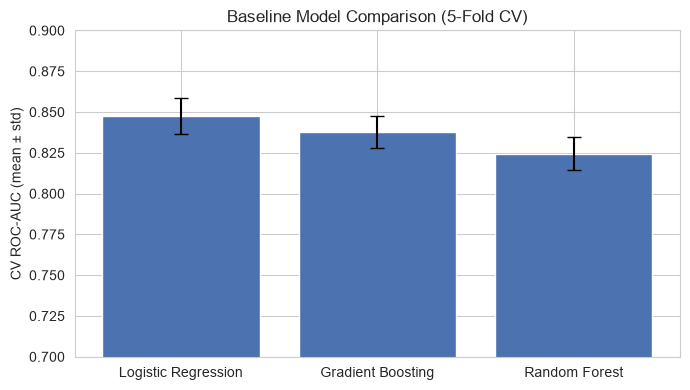

In [2]:
cv_results = cross_validate_candidates(X_train, y_train)
print(cv_results)

fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(cv_results["model"], cv_results["cv_roc_auc_mean"], yerr=cv_results["cv_roc_auc_std"], capsize=5, color="#4C72B0")
ax.set_ylabel("CV ROC-AUC (mean \u00b1 std)")
ax.set_title("Baseline Model Comparison (5-Fold CV)")
ax.set_ylim(0.7, 0.9)
plt.tight_layout()
plt.savefig(f"{FIGURES_DIR}/cv_model_comparison.png", dpi=150)
plt.show()

## Hyperparameter Tuning

All three models are tuned via grid search (not just the top CV performer) — cross-validation scores are noisy on a dataset this size, and a model's untuned ranking doesn't always predict its ranking after tuning.

In [3]:
tuned_models = {}
tuning_summary = []

for name in ["Logistic Regression", "Random Forest", "Gradient Boosting"]:
    best_estimator, best_params, best_score = tune_model(name, X_train, y_train)
    tuned_models[name] = best_estimator
    tuning_summary.append({"model": name, "best_cv_roc_auc": best_score, "best_params": best_params})
    print(f"{name}: best CV ROC-AUC = {best_score:.4f}")
    print(f"  best params: {best_params}")

tuning_df = pd.DataFrame(tuning_summary)

Logistic Regression: best CV ROC-AUC = 0.8477
  best params: {'model__C': 10}


Random Forest: best CV ROC-AUC = 0.8458
  best params: {'model__max_depth': 10, 'model__min_samples_leaf': 5, 'model__n_estimators': 300}


Gradient Boosting: best CV ROC-AUC = 0.8460
  best params: {'model__learning_rate': 0.05, 'model__max_depth': 5, 'model__max_iter': 100}


## Test Set Evaluation

This is the only point in the whole notebook where the test set is touched — everything above (model selection, tuning) used only the training set with cross-validation, so this evaluation is a genuinely unbiased estimate of real-world performance.

In [4]:
test_results = {}
comparison_rows = []

for name, model in tuned_models.items():
    result = evaluate_on_test(model, X_test, y_test)
    test_results[name] = result
    comparison_rows.append({
        "model": name,
        "accuracy": result["accuracy"],
        "precision": result["precision"],
        "recall": result["recall"],
        "f1": result["f1"],
        "roc_auc": result["roc_auc"],
    })

comparison_df = pd.DataFrame(comparison_rows).sort_values("roc_auc", ascending=False).reset_index(drop=True)
comparison_df

,model,accuracy,precision,recall,f1,roc_auc
0,Random Forest,0.755855,0.526690,0.791444,0.632479,0.845827
1,Logistic Regression,0.740241,0.506734,0.804813,0.621901,0.843884
2,Gradient Boosting,0.748758,0.517301,0.799465,0.628151,0.842148


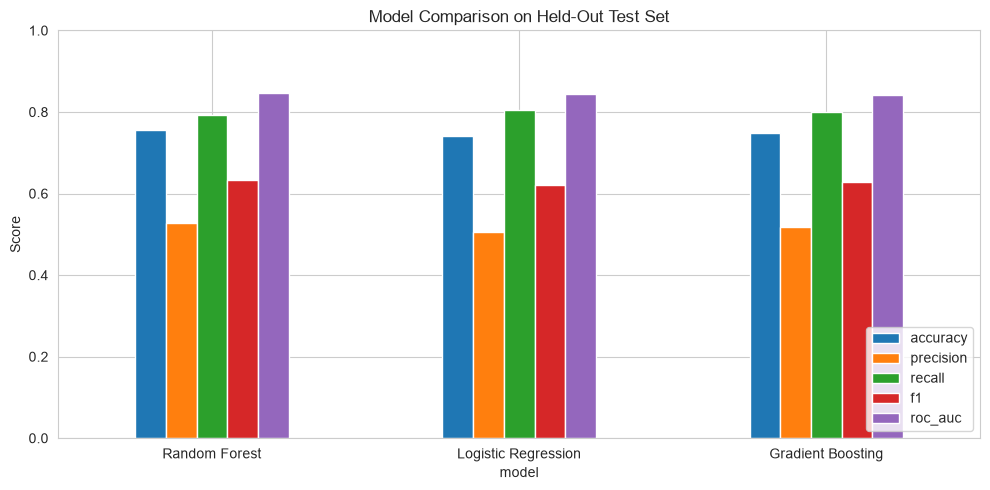

In [5]:
metrics = ["accuracy", "precision", "recall", "f1", "roc_auc"]
plot_df = comparison_df.set_index("model")[metrics]

fig, ax = plt.subplots(figsize=(10, 5))
plot_df.plot(kind="bar", ax=ax)
ax.set_title("Model Comparison on Held-Out Test Set")
ax.set_ylabel("Score")
ax.set_ylim(0, 1)
ax.legend(loc="lower right")
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig(f"{FIGURES_DIR}/test_set_model_comparison.png", dpi=150)
plt.show()

## ROC Curves

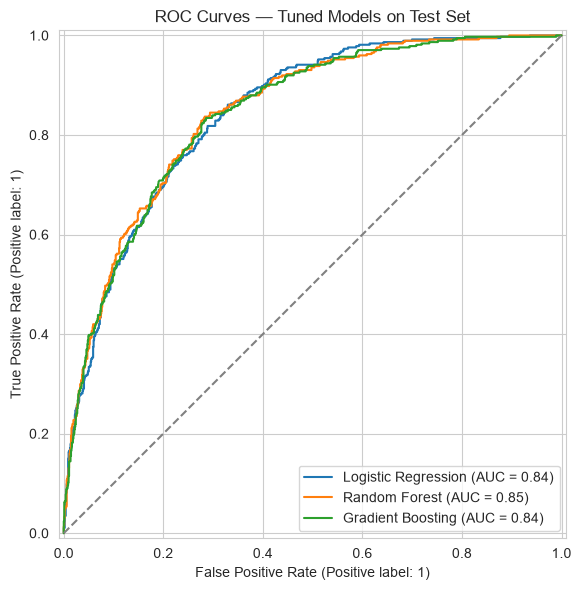

In [6]:
fig, ax = plt.subplots(figsize=(6, 6))
for name, model in tuned_models.items():
    RocCurveDisplay.from_estimator(model, X_test, y_test, ax=ax, name=name)
ax.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Random")
ax.set_title("ROC Curves — Tuned Models on Test Set")
plt.tight_layout()
plt.savefig(f"{FIGURES_DIR}/roc_curves.png", dpi=150)
plt.show()

## Confusion Matrix — Best Model

Selecting the best model by test ROC-AUC, then examining its confusion matrix. For a churn use case, false negatives (predicted-stay, actually-churned) are usually more costly than false positives — missing a customer who was about to leave means losing them entirely, whereas a false positive just means a wasted retention offer.

Best model by test ROC-AUC: Random Forest


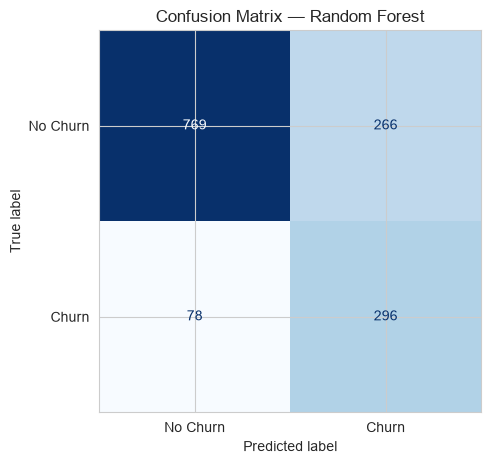

In [7]:
best_model_name = comparison_df.iloc[0]["model"]
best_model = tuned_models[best_model_name]
print(f"Best model by test ROC-AUC: {best_model_name}")

fig, ax = plt.subplots(figsize=(5, 5))
ConfusionMatrixDisplay(test_results[best_model_name]["confusion_matrix"], display_labels=["No Churn", "Churn"]).plot(ax=ax, cmap="Blues", colorbar=False)
ax.set_title(f"Confusion Matrix — {best_model_name}")
plt.tight_layout()
plt.savefig(f"{FIGURES_DIR}/confusion_matrix_best_model.png", dpi=150)
plt.show()

In [8]:
save_model(best_model, "../models/best_model.joblib")
print(f"Saved {best_model_name} to models/best_model.joblib")

comparison_df.to_csv("../reports/model_comparison.csv", index=False)
print("Saved comparison table to reports/model_comparison.csv")

Saved Random Forest to models/best_model.joblib
Saved comparison table to reports/model_comparison.csv


## Key Findings

- **Best model: Random Forest** (tuned: `n_estimators=300, max_depth=10, min_samples_leaf=5`), selected by test-set ROC-AUC (0.846). Test metrics: accuracy 0.756, precision 0.527, recall 0.791, F1 0.632.
- **All three tuned models converge to statistically indistinguishable performance** (ROC-AUC 0.842–0.846 on the test set, CV scores within 0.002 of each other). This is a meaningful finding in its own right: model choice mattered far less here than feature engineering did in notebook 02. Once the informative features (contract type, tenure, internet service, payment method) are in the training set, a linear model captures nearly as much signal as more flexible tree ensembles — which suggests the churn signal in this dataset is largely additive rather than driven by complex feature interactions.
- **High recall, moderate precision — and that's the right trade-off for this business problem.** The best model catches 79.1% of customers who actually churn (296 of 374 in the test set), at the cost of 266 false positives. In a retention context, a false negative (missing a customer about to leave) is far more costly than a false positive (an unnecessary retention offer to someone who wasn't going to churn) — so optimizing for recall over raw accuracy is a deliberate choice, not an artifact.
- **Class balancing was necessary, not optional**: without `class_weight="balanced"`, a model trained on 26.5% churn data tends to under-predict the minority class, since predicting "no churn" for everyone would already achieve ~73.5% accuracy while catching zero actual churners.
- **Honest caveat for further work**: the default 0.5 classification threshold was used throughout. In a real deployment, the threshold should be tuned explicitly against the actual dollar cost of a missed churner vs. a wasted retention offer, rather than left at the default — this would likely shift the precision/recall balance further toward recall given the asymmetric cost structure described above.

Best model saved to `models/best_model.joblib`. Full comparison table: `reports/model_comparison.csv`.